In [1]:
''' LOADING OF THE DATASET'''

import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")

print(df.head(20))
print("Shape of the DataFrame:", df.shape)

    gender   age  hypertension  heart_disease smoking_history    bmi  \
0   Female  80.0             0              1           never  25.19   
1   Female  54.0             0              0         No Info  27.32   
2     Male  28.0             0              0           never  27.32   
3   Female  36.0             0              0         current  23.45   
4     Male  76.0             1              1         current  20.14   
5   Female  20.0             0              0           never  27.32   
6   Female  44.0             0              0           never  19.31   
7   Female  79.0             0              0         No Info  23.86   
8     Male  42.0             0              0           never  33.64   
9   Female  32.0             0              0           never  27.32   
10  Female  53.0             0              0           never  27.32   
11  Female  54.0             0              0          former  54.70   
12  Female  78.0             0              0          former  3

In [2]:
''' Ex.No. 7 '''

# “HbA1c_level” and “blood_glucose_level” as input features and “diabetes” as target class

X = df[['HbA1c_level','blood_glucose_level']]
y = df['diabetes']

In [3]:
# Draw the graph with linearly separable line that separates the two distinct classes 
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

print("x_train : ","\n", x_train.head())
print("y_train : ","\n",y_train.head())

x_train :  
        HbA1c_level  blood_glucose_level
75220          3.5                   80
48955          5.7                  145
44966          4.0                  158
13568          5.0                  100
92727          4.5                   85
y_train :  
 75220    0
48955    1
44966    0
13568    0
92727    0
Name: diabetes, dtype: int64


In [4]:
# from sklearn.svm import SVC
# model = SVC(kernel='linear')

# model.fit(x_train,y_train)

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

model = LinearSVC()

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print(y_pred)

/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearSVC was fitted without feature names
  warnings.warn(


[1 1 1 ... 1 1 1]


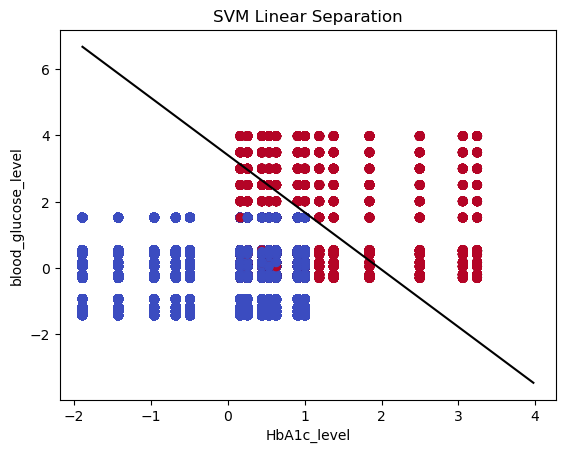

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(x_train[:, 0], x_train[:, 1],c=y_train,cmap='coolwarm')

w = model.coef_[0]
b = model.intercept_[0]

x_points = np.linspace(x_train[:,0].min(),
                       x_train[:,1].max(), 100)

y_points = -(w[0] * x_points + b) / w[1]

plt.plot(x_points, y_points, color='black')

plt.xlabel("HbA1c_level")
plt.ylabel("blood_glucose_level")
plt.title("SVM Linear Separation")
plt.show()

In [6]:
# Evaluate the model and calculate the accuracy of the model

from sklearn.metrics import mean_squared_error,accuracy_score
# mse = mean_squared_error(y_test,y_pred)
# print("Mean Squared Error:",mse)

a_score = accuracy_score(y_test,y_pred)
print("Acuuarcy:",a_score)

Acuuarcy: 0.0854


In [7]:
# Predict the target class value for “HbA1c=5 and blood_glucose_level-100”
x_new = np.array([[5,100]])
y_new = model.predict(x_new)

if(y_new):
    print("Diabetic")
else :
    print("Non-Diabetic")

Diabetic


In [8]:
# Justify the statement. Model yields 100% accuracy but it fails to predict the target class for new dataset
''' Overfitting : Model memorizes data points, Decision boundary fits too tightly around training data.

Noise Learning : Model learns random noise as if it were important.

Small Dataset : Not enough variation to generalize.

No Proper Validation : Model tested only on training data.

Data Distribution Change : New dataset may have different distribution. '''

' Overfitting : Model memorizes data points, Decision boundary fits too tightly around training data.\n\nNoise Learning : Model learns random noise as if it were important.\n\nSmall Dataset : Not enough variation to generalize.\n\nNo Proper Validation : Model tested only on training data.\n\nData Distribution Change : New dataset may have different distribution. '

In [9]:
'''Ex.No.8'''
'''Predict the value of target class for the new input “HbA1c=5 and blood_glucose_level-100”
using the models build in Ex.No.4, 5 and 7. Apply ensemble approach on these three models
and compare the results from all the three models (M1,M2,M3) with ensemble technique'''

import joblib

model1 = joblib.load("model1.pkl")
model2 = joblib.load("model2.pkl")

print("Models Loaded Successfully")


Models Loaded Successfully


In [10]:
model3 = model

In [11]:
new_data = np.array([[5, 100]])

# Prediction from Model 1
pred1 = model1.predict(new_data)

# Prediction from Model 2
pred2 = model2.predict(new_data)

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [12]:
print("M1 Prediction:", pred1[0])
print("M2 Prediction:", pred2[0])
print("M3 (SVM) Prediction:", y_new[0])

M1 Prediction: 1
M2 Prediction: 1
M3 (SVM) Prediction: 1


In [13]:
import numpy as np

predictions = np.array([pred1[0], pred2[0], y_new[0]])

ensemble_prediction = np.bincount(predictions).argmax()

print("Ensemble Prediction:", ensemble_prediction)

Ensemble Prediction: 1


In [14]:
print("\nComparison of Models")
print("Model 1:", pred1[0])
print("Model 2:", pred2[0])
print("Model 3 (SVM):", y_new[0])
print("Ensemble:", ensemble_prediction)


Comparison of Models
Model 1: 1
Model 2: 1
Model 3 (SVM): 1
Ensemble: 1


In [15]:
'''Ex.No.9'''
'''Apply k-Means algorithm on the diabetes dataset and evaluate the model accuracy. Assume a
random number for number of clusters to be formed.'''

X = df.drop('diabetes' , axis =1)
y = df['diabetes']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['gender'] = le.fit_transform(X['gender'])
X['smoking_history'] = le.fit_transform(X['smoking_history'])

#Normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.cluster import KMeans
model4 = KMeans(n_clusters = 2,random_state = 42)
model4.fit(X_scaled)

clusters = model4.labels_

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


In [17]:
# Check both possibilities and take best accuracy
accuracy1 = accuracy_score(y, clusters)
accuracy2 = accuracy_score(y, 1 - clusters)

accuracy = max(accuracy1, accuracy2)

print("K-Means Accuracy:", accuracy)

K-Means Accuracy: 0.5703


In [18]:
'''Ex.No.10'''
'''Apply DBSCAN algorithm on the diabetes dataset. Assume a random value for eps and
minpts. Analyse the code with various random value for eps and minpts and Justify how these
input parameters affect the cluster formed.'''

X_small = X[['HbA1c_level', 'blood_glucose_level']]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['gender'] = le.fit_transform(X['gender'])
X['smoking_history'] = le.fit_transform(X['smoking_history'])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.cluster import DBSCAN

# Assume random values
model = DBSCAN(eps=1.0, min_samples=5)
clusters = model.fit_predict(X_scaled)

print("Unique clusters formed:", set(clusters))

Unique clusters formed: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(-1)}


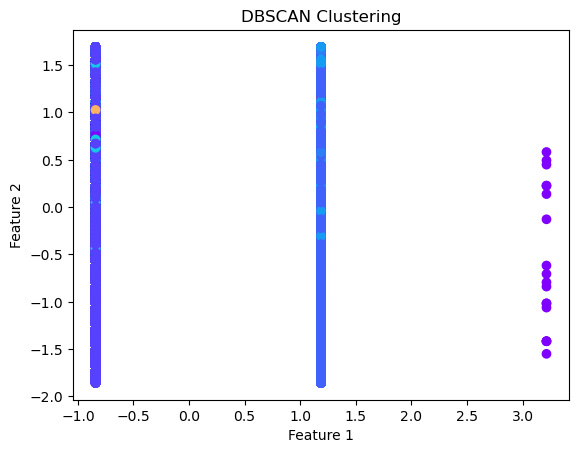

In [20]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [21]:
model1 = DBSCAN(eps=0.5, min_samples=10)
clusters = model1.fit_predict(X_scaled)

print("Unique clusters formed:", set(clusters))

Unique clusters formed: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41), np.int32(42), np.int32(43), np.int32(44), np.int32(45), np.int32(46), np.int32(47), np.int32(48), np.int32(49), np.int32(50), np.int32(51), np.int32(52), np.int32(53), np.int32(54), np.int32(55), np.int32(56), np.int32(57), np.int32(58), np.int32(59), np.int32(60), np.int32(61), np.int32(62), np.int32(63), np.int32(64), np.int32(65), np.int32(66), np.int32(67), np.int32(68), np.int32(69), np.in

In [22]:
model2 = DBSCAN(eps=1.0, min_samples=8)
clusters = model2.fit_predict(X_scaled)

print("Unique clusters formed:", set(clusters))

Unique clusters formed: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(-1)}


In [23]:
''' Small eps : Tight clusters, more noise,fragmented clusters
    Large eps : Large clusters , less noise, may merge separate clusters
    Small min_samples: Easy to form clusters,less noise
    Large min_samples : Hard to form clusters,more noise
'''

' Small eps : Tight clusters, more noise,fragmented clusters\n    Large eps : Large clusters , less noise, may merge separate clusters\n    Small min_samples: Easy to form clusters,less noise\n    Large min_samples : Hard to form clusters,more noise\n'